In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import gmean

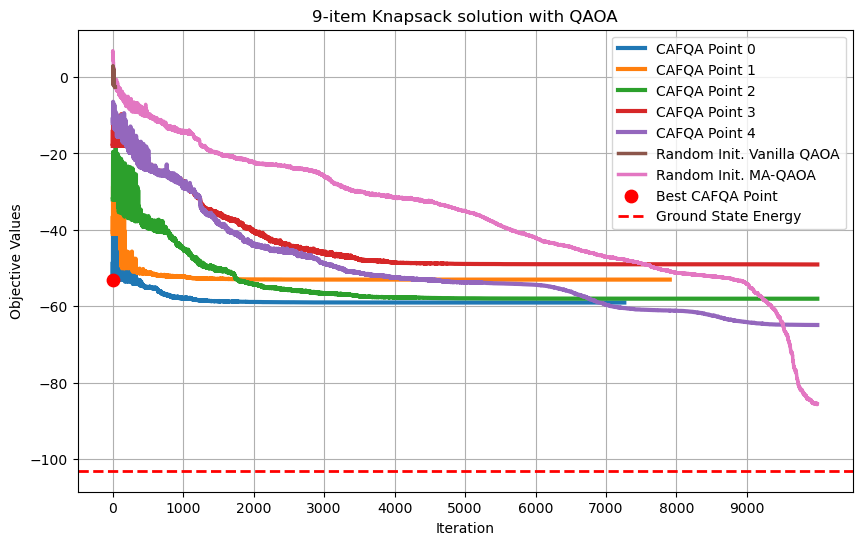

In [10]:
#Approx Ratio
cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Maxcut/Complete_Graphs/12_qbs/result_2.npy', allow_pickle=True).item()

# Dynamically find all 'task_' keys in Task_results
tasks = [key for key in cafqa_diff_points_data['Task_results'] if key.startswith('task_')]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}
exact_energy = cafqa_diff_points_data['Exact_Ground_State_Energy']
# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point {i}', linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', linewidth=2.5,zorder=10)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA', linewidth=2.5)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']
# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.scatter(0, obj_values['task_0'][0], color='red', s=80, zorder=5, label='Best CAFQA Point')
plt.axhline(y=exact_energy, color='red', linestyle='--', linewidth=2, label='Ground State Energy')
plt.legend()
plt.grid()
plt.title('9-item Knapsack solution with QAOA')
plt.xticks(ticks=np.arange(0, 10000, 1000))
# plt.savefig('../plots/knapsack_qaoa_9_item.png', dpi=500, bbox_inches='tight')
plt.show()

In [11]:
cafqa_diff_points_data['Task_results']['task_0']

{'task_name': 'task_0',
 'result':  message: Optimization terminated successfully.
  success: True
   status: 1
      fun: -58.99986787801112
        x: [ 1.573e+00  3.092e+00 ...  3.142e+00  4.712e+00]
     nfev: 7261
    maxcv: 0.0,
 'fitness_val': np.float64(-53.0),
 'obj_values': [array(-53.),
  array(-48.40302306),
  array(-53.),
  array(-41.04785995),
  array(-41.04785995),
  array(-45.1851392),
  array(-45.1851392),
  array(-40.58816226),
  array(-48.86272075),
  array(-49.32241845),
  array(-53.),
  array(-44.26574381),
  array(-47.95117409),
  array(-49.32241845),
  array(-41.04785995),
  array(-32.77330146),
  array(-36.45088301),
  array(-45.1851392),
  array(-44.72544151),
  array(-45.1851392),
  array(-37.3702784),
  array(-45.1851392),
  array(-44.72544151),
  array(-36.45088301),
  array(-49.32241845),
  array(-48.40302306),
  array(-53.),
  array(-49.32241845),
  array(-48.86272075),
  array(-53.),
  array(-45.1851392),
  array(-49.32241845),
  array(-41.50755765),
  ar

In [3]:
def compute_relative_errors(task_num, idx):
    cafqa_val = cafqa_diff_points_data['Task_results'][f'task_{task_num}']['obj_values'][idx]
    random_val = cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'][idx]
    cafqa_err = np.abs((cafqa_val - exact_energy) / exact_energy)
    random_err = np.abs((random_val - exact_energy) / exact_energy)
    print(f"CAFQA relative error: {np.round(cafqa_err, 3)}")
    print(f"Random MA-QAOA relative error: {np.round(random_err, 3)}")
    return np.round(cafqa_err, 3), np.round(random_err, 3)

# Example usage:
compute_relative_errors(1,40)

CAFQA relative error: 0.572
Random MA-QAOA relative error: 0.8


(np.float64(0.572), np.float64(0.8))

In [4]:
k_reg_cafqa_rel_err_12 = [0.137,0.106,0.259,0.155,0.167,0.268,0.039,0.09,0.228,0.15]
k_reg_random_rel_err_12 = [0.167,0.125,0.291,0.149,0.225,0.207,0.162,0.175,0.172,0.204]

In [5]:
kp_cafqa_rel_err_4 = [0.017, 0.101, 0.04, 0.021 , 0.018, 0.031, 0.019, 0.012, 0.005, 0.007]
kp_random_rel_err_4 = [0.728, 0.858, 0.722, 0.246, 0.64, 0.537, 0.605, 0.682, 0.63, 0.63 ]

kp_cafqa_rel_err_9 = [0.134, 0.053, 0.045, 0.021, 0.057, 0.218,0.068, 0.221,0.012,0.032 ]
kp_random_rel_err_9 = [0.247, 0.901, 0.397, 0.302, 0.46, 0.121,0.097, 0.408,0.142, 0.159]

kp_cafqa_rel_err_12 = [0.236,0.309,0.197, 0.309,0.347,0.696, 0.373,0.443,0.496,0.395 ]
kp_random_rel_err_12 = [0.309,0.495,0.695, 0.326,0.42,0.975, 0.389,0.558, 0.395,0.676]

In [6]:
complete_graph_cafqa_rel_err_8 = [0.003, 0.007, 0.053, 0.004, 0.032, 0.006, 0.001, 0.042, 0.143 , 0.002]
complete_graph_random_rel_err_8 = [0.507, 0.054, 0.004, 0.026, 0.002, 0.089, 0.734, 0.003, 0.244, 0.133]

complete_graph_cafqa_rel_err_12 = [0.148,0.37, 0.228,0.122, 0.037,0.339, 0.039, 0.149, 0.001, 0.279]
complete_graph_random_rel_err_12 = [0.09, 0.169, 0.069, 0.648, 0.445,0.771, 0.402, 0.106, 0.196, 0.225]

complete_graph_cafqa_rel_err_16 = [0.583, 0.627, 0.525, 0.575, 0.527, 0.588, 0.528, 0.339, 0.617, 0.602]
complete_graph_random_rel_err_16 = [0.632, 0.579, 0.602, 0.752, 0.618, 0.75, 0.656, 0.564, 0.756, 0.9 ]

In [7]:
# def print_mean_and_std(arr1, arr2, label1="cafqa", label2="random"):
#     mean1 = np.mean(arr1)
#     std1 = np.std(arr1)
#     mean2 = np.mean(arr2)
#     std2 = np.std(arr2)
#     print(f"{label1}: mean={mean1:.3f}, std={std1:.3f}")
#     print(f"{label2}: mean={mean2:.3f}, std={std2:.3f}")

def print_gmean_and_std(arr1, arr2, label1="cafqa", label2="random"):
    gmean1 = gmean(arr1)
    std1 = np.std(arr1)
    gmean2 = gmean(arr2)
    std2 = np.std(arr2)
    print(f"{label1}: gmean={gmean1:.3f}, std={std1:.3f}")
    print(f"{label2}: gmean={gmean2:.3f}, std={std2:.3f}")

print_gmean_and_std(k_reg_cafqa_rel_err_12,k_reg_random_rel_err_12)

cafqa: gmean=0.141, std=0.070
random: gmean=0.183, std=0.044


In [8]:
cafqa_diff_points_data['Task_results'].keys()

dict_keys(['task_0', 'task_1', 'task_2', 'Random_MA-QAOA', 'Vanilla_task'])

In [9]:
cafqa_diff_points_data['Task_results']['Vanilla_task']['approx_ratio'],cafqa_diff_points_data['Task_results']['task_1']['approx_ratio']

(0.6816816326530619, 1.0)

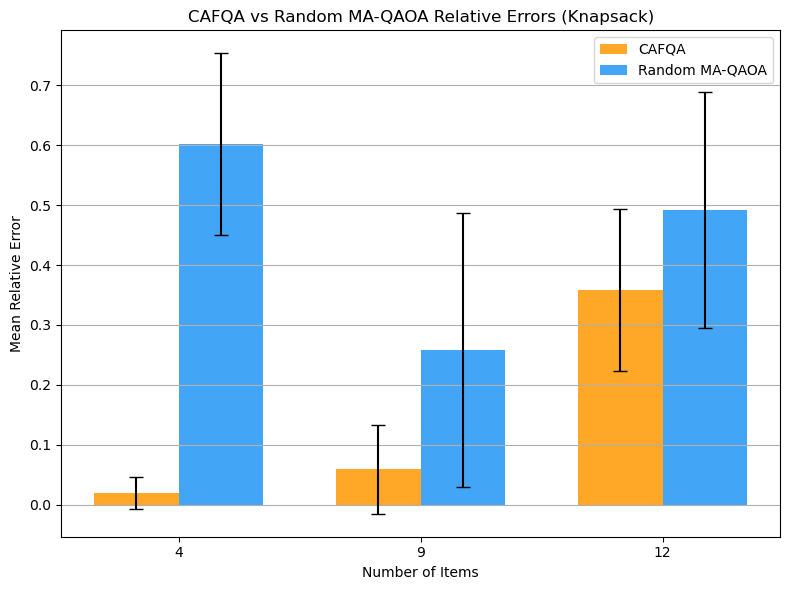

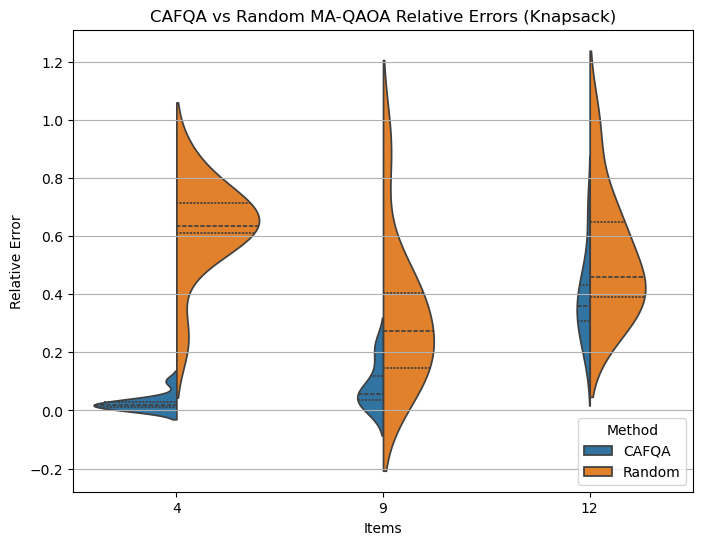

In [18]:
# Calculate means and standard deviations for each group
methods = ['CAFQA', 'CAFQA', 'CAFQA', 'Random', 'Random', 'Random']
item_sizes = [4, 9, 12, 4, 9, 12]
means = [
    gmean(kp_cafqa_rel_err_4),
    gmean(kp_cafqa_rel_err_9),
    gmean(kp_cafqa_rel_err_12),
    gmean(kp_random_rel_err_4),
    gmean(kp_random_rel_err_9),
    gmean(kp_random_rel_err_12)
]
stds = [
    np.std(kp_cafqa_rel_err_4),
    np.std(kp_cafqa_rel_err_9),
    np.std(kp_cafqa_rel_err_12),
    np.std(kp_random_rel_err_4),
    np.std(kp_random_rel_err_9),
    np.std(kp_random_rel_err_12)
]

import matplotlib.pyplot as plt

# Set up bar positions so that CAFQA and Random for each item size are grouped together
n_groups = 3  # 4, 9, 12 items
bar_width = 0.35
index = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(8, 6))

# CAFQA bars (left in each group)
ax.bar(index - bar_width/2, means[:3], bar_width, yerr=stds[:3], label='CAFQA', color='#FFA726', capsize=5)
# Random bars (right in each group)
ax.bar(index + bar_width/2, means[3:], bar_width, yerr=stds[3:], label='Random MA-QAOA', color='#42A5F5', capsize=5)

# Set x-ticks and labels
ax.set_xticks(index)
ax.set_xticklabels(['4', '9', '12'])
ax.set_xlabel('Number of Items')
ax.set_ylabel('Mean Relative Error')
ax.set_title('CAFQA vs Random MA-QAOA Relative Errors (Knapsack)')
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()

# Prepare data for boxplot with grouped categories for CAFQA and Random
data = [
    kp_cafqa_rel_err_4,
    kp_cafqa_rel_err_9,
    kp_cafqa_rel_err_12,
    kp_random_rel_err_4,
    kp_random_rel_err_9,
    kp_random_rel_err_12
]
labels = [
    "CAFQA 4", "CAFQA 9", "CAFQA 12",
    "Random 4", "Random 9", "Random 12"
]

# Assign group and item size for each box
group = ['CAFQA'] * 3 + ['Random'] * 3
item_size = [4, 9, 12] * 2

# Flatten data for DataFrame
flat_data = []
flat_group = []
flat_item_size = []
for d, g, n in zip(data, group, item_size):
    flat_data.extend(d)
    flat_group.extend([g] * len(d))
    flat_item_size.extend([n] * len(d))

df_box = pd.DataFrame({
    'Relative Error': flat_data,
    'Method': flat_group,
    'Items': flat_item_size
})

plt.figure(figsize=(8, 6))
sns.violinplot(data=df_box, x='Items', y='Relative Error', hue='Method', split=True, inner='quartile')
plt.title("CAFQA vs Random MA-QAOA Relative Errors (Knapsack)")
plt.grid(axis='y')
plt.show()

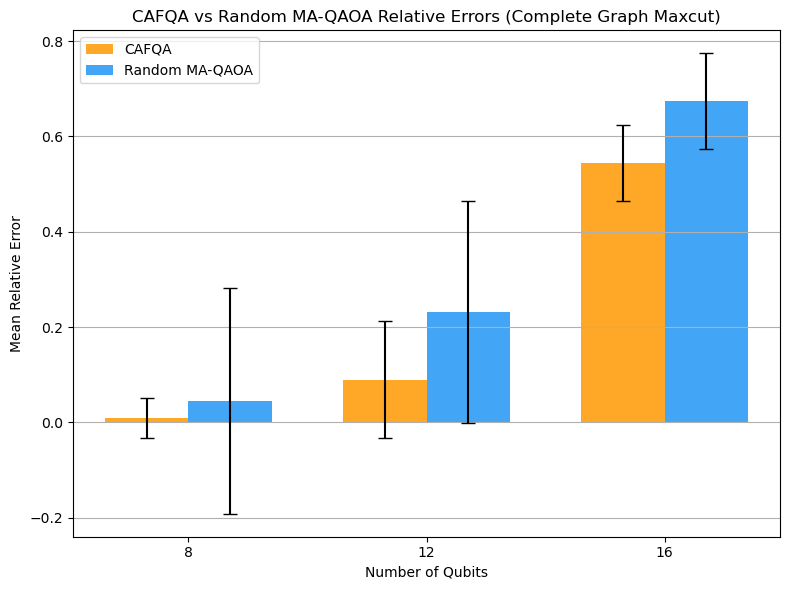

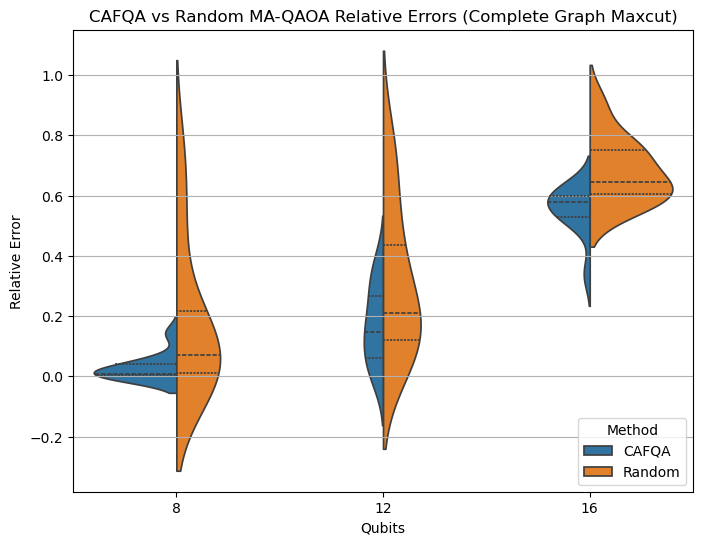

In [19]:
# Calculate means and standard deviations for each group
methods = ['CAFQA', 'CAFQA', 'CAFQA', 'Random', 'Random', 'Random']
item_sizes = [8, 12, 16, 8, 12, 16]
means = [
    gmean(complete_graph_cafqa_rel_err_8),
    gmean(complete_graph_cafqa_rel_err_12),
    gmean(complete_graph_cafqa_rel_err_16),
    gmean(complete_graph_random_rel_err_8),
    gmean(complete_graph_random_rel_err_12),
    gmean(complete_graph_random_rel_err_16)
]
stds = [
    np.std(complete_graph_cafqa_rel_err_8),
    np.std(complete_graph_cafqa_rel_err_12),
    np.std(complete_graph_cafqa_rel_err_16),
    np.std(complete_graph_random_rel_err_8),
    np.std(complete_graph_random_rel_err_12),
    np.std(complete_graph_random_rel_err_16)
]

# Set up bar positions so that CAFQA and Random for each item size are grouped together
n_groups = 3  # 8, 12, 16 qubits
bar_width = 0.35
index = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(8, 6))

# CAFQA bars (left in each group)
ax.bar(index - bar_width/2, means[:3], bar_width, yerr=stds[:3], label='CAFQA', color='#FFA726', capsize=5)
# Random bars (right in each group)
ax.bar(index + bar_width/2, means[3:], bar_width, yerr=stds[3:], label='Random MA-QAOA', color='#42A5F5', capsize=5)

# Set x-ticks and labels
ax.set_xticks(index)
ax.set_xticklabels(['8', '12', '16'])
ax.set_xlabel('Number of Qubits')
ax.set_ylabel('Mean Relative Error')
ax.set_title('CAFQA vs Random MA-QAOA Relative Errors (Complete Graph Maxcut)')
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()

# Prepare data for boxplot with grouped categories for CAFQA and Random
data = [
    complete_graph_cafqa_rel_err_8,
    complete_graph_cafqa_rel_err_12,
    complete_graph_cafqa_rel_err_16,
    complete_graph_random_rel_err_8,
    complete_graph_random_rel_err_12,
    complete_graph_random_rel_err_16
]
labels = [
    "CAFQA 8", "CAFQA 12", "CAFQA 16",
    "Random 8", "Random 12", "Random 16"
]

# Assign group and item size for each box
group = ['CAFQA'] * 3 + ['Random'] * 3
item_size = [8, 12, 16] * 2

# Flatten data for DataFrame
flat_data = []
flat_group = []
flat_item_size = []
for d, g, n in zip(data, group, item_size):
    flat_data.extend(d)
    flat_group.extend([g] * len(d))
    flat_item_size.extend([n] * len(d))

df_box = pd.DataFrame({
    'Relative Error': flat_data,
    'Method': flat_group,
    'Qubits': flat_item_size
})

plt.figure(figsize=(8, 6))
sns.violinplot(data=df_box, x='Qubits', y='Relative Error', hue='Method', split=True, inner='quartile')
plt.title("CAFQA vs Random MA-QAOA Relative Errors (Complete Graph Maxcut)")
plt.grid(axis='y')
plt.show()

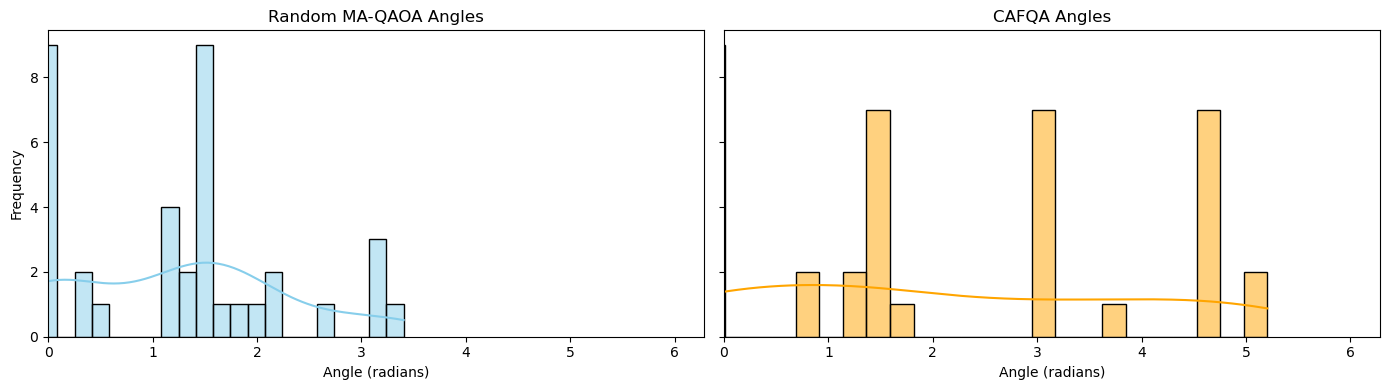

In [11]:
random_fin_angles = cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['result'].x

cafqa_fin_angles = cafqa_diff_points_data['Task_results']['task_1']['result'].x  # Use the provided angles array for CAFQA

fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# Plot for Random MA-QAOA angles
sns.histplot(random_fin_angles, bins=30, kde=True, color='skyblue', ax=axs[0])
axs[0].set_xlabel('Angle (radians)')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Random MA-QAOA Angles')
axs[0].set_xlim(0, 2 * np.pi)

# Plot for CAFQA angles
sns.histplot(cafqa_fin_angles, bins=30, kde=True, color='orange', ax=axs[1])
axs[1].set_xlabel('Angle (radians)')
axs[1].set_title('CAFQA Angles')
axs[1].set_xlim(0, 2 * np.pi)

plt.tight_layout()
plt.show()

In [12]:
# Generate and print the relative errors for Random MA-QAOA and CAFQA (best of 4) for a single instance
num_qubits = 12  # or any value you want to analyze
i = 1
  # instance index

data = np.load(f'../np_data/Final_Data_Collection/Maxcut/Complete_Graphs/Median_Random_Angles/{num_qubits}_qbs/result_{i}.npy', allow_pickle=True).item()
exact_energy = data['Exact_Ground_State_Energy']
random_fin_energy = data['Task_results']['Random_MA-QAOA']['final_energy']
min_cafqa_fin_energy = min(
    data['Task_results'][task]['final_energy']
    for task in data['Task_results'] if task.startswith('task_')
)
random_err = abs((exact_energy - random_fin_energy) / exact_energy)
cafqa_err = abs((exact_energy - min_cafqa_fin_energy) / exact_energy)

print("Random MA-QAOA relative error:", random_err)
print("CAFQA (best of 4) relative error:", cafqa_err)


Random MA-QAOA relative error: 0.166671403651369
CAFQA (best of 4) relative error: 0.09375030982180674


In [13]:
def compute_cafqa_vs_random_stats(num_qubits):
    random_approx_ratios = []
    cafqa_approx_ratios = []
    cafqa_accuracies = []
    random_relative_errors = []
    cafqa_relative_errors = []

    for i in range(1, 6):
        data = np.load(f'../np_data/Final_Data_Collection/Maxcut/Complete_Graphs/{num_qubits}_qbs/result_{i}.npy', allow_pickle=True).item()
        random_ratio = data['Task_results']['Random_MA-QAOA']['approx_ratio']
        random_fin_energy = data['Task_results']['Random_MA-QAOA']['final_energy']
        random_approx_ratios.append(random_ratio)
        exact_energy = data['Exact_Ground_State_Energy']
        max_approx_ratio = max(
            data['Task_results'][task]['approx_ratio']
            for task in data['Task_results'] if task.startswith('task_')
        )

        min_cafqa_fin_energy = min(
            data['Task_results'][task]['final_energy']
            for task in data['Task_results'] if task.startswith('task_')
        )

        random_err = abs((exact_energy - random_fin_energy) / exact_energy)
        cafqa_err = abs((exact_energy - min_cafqa_fin_energy) / exact_energy)
        random_relative_errors.append(random_err)
        cafqa_relative_errors.append(cafqa_err)

        cafqa_approx_ratios.append(max_approx_ratio)

        cafqa_accuracy = data['CAFQA_initialization_energy'] / exact_energy
        cafqa_accuracies.append(cafqa_accuracy)

    random_std = np.std(random_approx_ratios)
    cafqa_std = np.std(cafqa_approx_ratios)
    random_relerr_std = np.std(random_relative_errors)
    cafqa_relerr_std = np.std(cafqa_relative_errors)

    avg_random_approx_ratio = gmean(random_approx_ratios)
    avg_cafqa_approx_ratio = gmean(cafqa_approx_ratios)

    avg_random_relative_error = gmean(random_relative_errors)
    avg_cafqa_relative_error = gmean(cafqa_relative_errors)
    
    mean_cafqa_accuracy = gmean(cafqa_accuracies)

    print(f"Geometric mean CAFQA accuracy: {mean_cafqa_accuracy:.4f}")
    print(f"Random MA-QAOA: {avg_random_approx_ratio:.4f} ± {random_std:.4f}")
    print(f"CAFQA (best of 4): {avg_cafqa_approx_ratio:.4f} ± {cafqa_std:.4f}")
    print(f"Geometric mean relative error (Random MA-QAOA vs exact): {avg_random_relative_error:.4f} ± {random_relerr_std:.4f}")
    print(f"Geometric mean relative error (CAFQA best vs exact): {avg_cafqa_relative_error:.4f} ± {cafqa_relerr_std:.4f}")
    return {
        'mean_cafqa_accuracy': mean_cafqa_accuracy,
        'avg_random_approx_ratio': avg_random_approx_ratio,
        'random_std': random_std,
        'avg_cafqa_approx_ratio': avg_cafqa_approx_ratio,
        'cafqa_std': cafqa_std,
        'avg_random_relative_error': avg_random_relative_error,
        'random_relerr_std': random_relerr_std,
        'avg_cafqa_relative_error': avg_cafqa_relative_error,
        'cafqa_relerr_std': cafqa_relerr_std,
    }

compute_cafqa_vs_random_stats(16)

Geometric mean CAFQA accuracy: 0.1820
Random MA-QAOA: 0.8747 ± 0.0158
CAFQA (best of 4): 0.8890 ± 0.0076
Geometric mean relative error (Random MA-QAOA vs exact): 0.6285 ± 0.0635
Geometric mean relative error (CAFQA best vs exact): 0.5632 ± 0.0402


{'mean_cafqa_accuracy': np.float64(0.1819708877767625),
 'avg_random_approx_ratio': np.float64(0.874736225226564),
 'random_std': np.float64(0.015839939917345267),
 'avg_cafqa_approx_ratio': np.float64(0.8889882785294957),
 'cafqa_std': np.float64(0.0076240920544974645),
 'avg_random_relative_error': np.float64(0.6285422302052099),
 'random_relerr_std': np.float64(0.06349897058604002),
 'avg_cafqa_relative_error': np.float64(0.5632176772787963),
 'cafqa_relerr_std': np.float64(0.04018698137711581)}

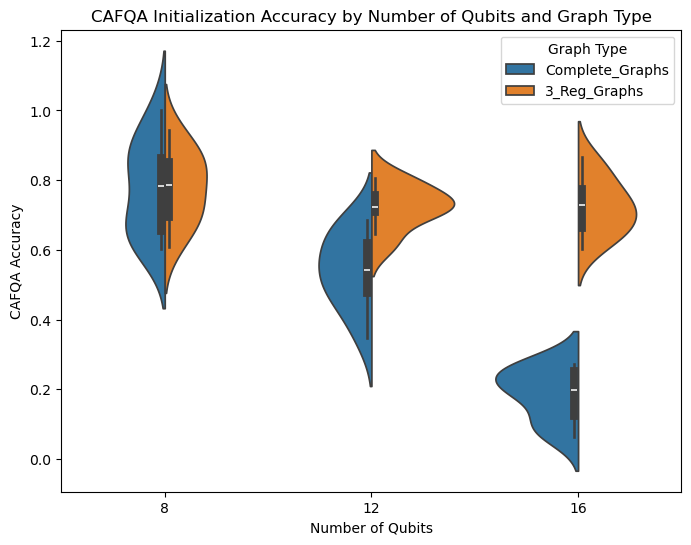

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

#1000 Gens not 10k 
# Collect CAFQA accuracy data for both Maxcut and K_Reg_Graphs
cafqa_accuracies = []
graph_types = []
num_qubits_col = []

num_qubits_list = [8, 12, 16]
graph_categories = ['Complete_Graphs', '3_Reg_Graphs']

for graph_type in graph_categories:
    for num_qubits in num_qubits_list:
        for idx in range(1, 11):
            if graph_type == 'Complete_Graphs':
                data_path = f'../np_data/Final_Data_Collection/Maxcut/Complete_Graphs/{num_qubits}_qbs/result_{idx}.npy'
            else:
                data_path = f'../np_data/Final_Data_Collection/Maxcut/K_Reg_Graphs/{num_qubits}_qbs/result_{idx}.npy'
            if not os.path.exists(data_path):
                continue
            data = np.load(data_path, allow_pickle=True).item()
            accuracy = data['CAFQA_initialization_energy'] / data['Exact_Ground_State_Energy']
            cafqa_accuracies.append(accuracy)
            graph_types.append(graph_type)
            num_qubits_col.append(num_qubits)

# Create DataFrame for plotting
df = pd.DataFrame({
    'CAFQA Accuracy': cafqa_accuracies,
    'Number of Qubits': num_qubits_col,
    'Graph Type': graph_types
})

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=df,
    x='Number of Qubits',
    y='CAFQA Accuracy',
    hue='Graph Type',
    split=True
)
plt.xlabel('Number of Qubits')
plt.ylabel('CAFQA Accuracy')
plt.title('CAFQA Initialization Accuracy by Number of Qubits and Graph Type')
plt.legend(title='Graph Type')
# plt.savefig('../plots/maxcut_cafqa_accuracy_violinplot.png', dpi=500, bbox_inches='tight')
plt.show()

In [15]:
teague_10qb_data = np.load('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy', allow_pickle=True).item()
exact_energy = teague_10qb_data['Exact_Ground_State_Energy'] if 'Exact_Ground_State_Energy' in teague_10qb_data else None

if exact_energy is None:
    # Try to infer from best of all tasks
    exact_energy = min(
        teague_10qb_data['Task_results'][task]['final_energy']
        for task in teague_10qb_data['Task_results']
        if 'final_energy' in teague_10qb_data['Task_results'][task]
    )

random_final_energy = teague_10qb_data['Task_results']['Random_MA-QAOA']['final_energy']
cafqa_final_energy = min(
    teague_10qb_data['Task_results'][task]['final_energy']
    for task in teague_10qb_data['Task_results']
    if task.startswith('task_')
)

random_rel_error = abs((exact_energy - random_final_energy) / exact_energy)
cafqa_rel_error = abs((exact_energy - cafqa_final_energy) / exact_energy)

print(f"Random MA-QAOA relative error: {random_rel_error:.4f}")
print(f"CAFQA (best of 5) relative error: {cafqa_rel_error:.4f}")



Random MA-QAOA relative error: 0.6014
CAFQA (best of 5) relative error: 0.0000


# Knapsack 

In [16]:
def compute_cafqa_vs_random_stats_no_approx(num_items):
    random_relative_error = 0 
    cafqa_relative_error = 0

    cafqa_accuracies = []
    random_relative_errors = []
    cafqa_relative_errors = []

    for i in range(1, 11):
        data = np.load(f'../np_data/Final_Data_Collection/Knapsack/{num_items}_items/result_{i}.npy', allow_pickle=True).item()
        random_fin_energy = data['Task_results']['Random_MA-QAOA']['final_energy']
        exact_energy = data['Exact_Ground_State_Energy']

        min_cafqa_fin_energy = min(
            data['Task_results'][task]['final_energy']
            for task in data['Task_results'] if task.startswith('task_')
        )

        random_err = abs((exact_energy - random_fin_energy) / exact_energy)
        cafqa_err = abs((exact_energy - min_cafqa_fin_energy) / exact_energy)
        random_relative_error += random_err
        cafqa_relative_error += cafqa_err
        random_relative_errors.append(random_err)
        cafqa_relative_errors.append(cafqa_err)

        cafqa_accuracy = data['CAFQA_initialization_energy'] / exact_energy
        cafqa_accuracies.append(cafqa_accuracy)

    random_relerr_std = np.std(random_relative_errors)
    cafqa_relerr_std = np.std(cafqa_relative_errors)

    avg_random_relative_error = random_relative_error / 10
    avg_cafqa_relative_error = cafqa_relative_error / 10
    
    mean_cafqa_accuracy = np.mean(cafqa_accuracies)

    print(f"Mean CAFQA accuracy: {mean_cafqa_accuracy:.4f}")
    print(f"Mean relative error (Random MA-QAOA vs exact): {avg_random_relative_error:.4f} ± {random_relerr_std:.4f}")
    print(f"Mean relative error (CAFQA best vs exact): {avg_cafqa_relative_error:.4f} ± {cafqa_relerr_std:.4f}")
    return {
        'mean_cafqa_accuracy': mean_cafqa_accuracy,
        'avg_random_relative_error': avg_random_relative_error,
        'random_relerr_std': random_relerr_std,
        'avg_cafqa_relative_error': avg_cafqa_relative_error,
        'cafqa_relerr_std': cafqa_relerr_std,
    }

compute_cafqa_vs_random_stats_no_approx(12)

Mean CAFQA accuracy: 0.2068
Mean relative error (Random MA-QAOA vs exact): 0.4652 ± 0.1295
Mean relative error (CAFQA best vs exact): 0.3541 ± 0.0904


{'mean_cafqa_accuracy': np.float64(0.20675407362967385),
 'avg_random_relative_error': np.float64(0.4651799829655648),
 'random_relerr_std': np.float64(0.1295249717139555),
 'avg_cafqa_relative_error': np.float64(0.3541041589057981),
 'cafqa_relerr_std': np.float64(0.09036136333119064)}

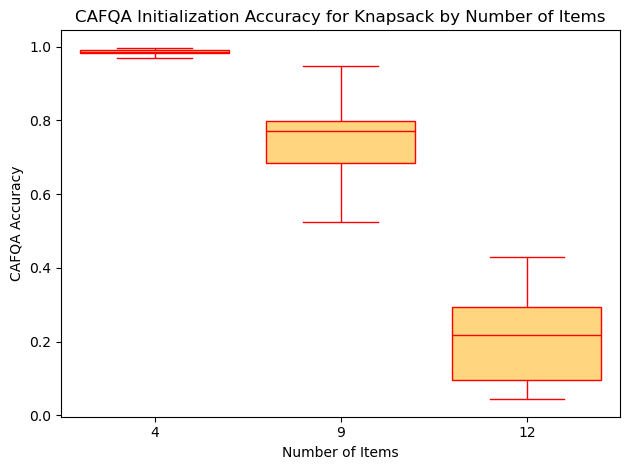

<Axes: xlabel='Number of Items', ylabel='CAFQA Accuracy'>

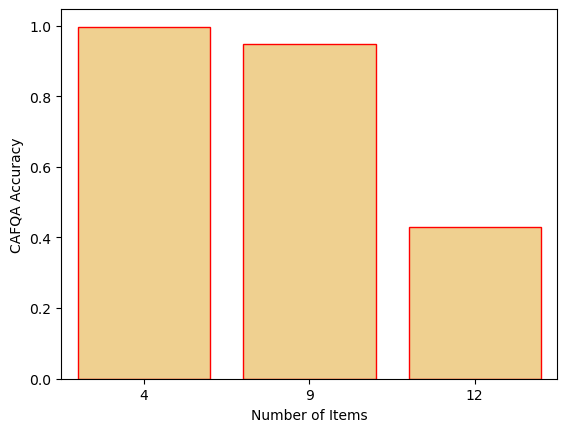

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Collect CAFQA accuracy data for Knapsack with different item sizes
cafqa_accuracies = []
item_sizes = []

item_sizes_list = [4, 9, 12]

for num_items in item_sizes_list:
    for idx in range(1, 11):
        data_path = f'../np_data/Final_Data_Collection/Knapsack/{num_items}_items/result_{idx}.npy'
        if not os.path.exists(data_path):
            continue
        data = np.load(data_path, allow_pickle=True).item()
        accuracy = data['CAFQA_initialization_energy'] / data['Exact_Ground_State_Energy']
        cafqa_accuracies.append(accuracy)
        item_sizes.append(num_items)

# Create DataFrame for plotting
df_knapsack = pd.DataFrame({
    'CAFQA Accuracy': cafqa_accuracies,
    'Number of Items': item_sizes
})

# Custom boxplot with light orange color
sns.boxplot(
    data=df_knapsack,
    x='Number of Items',
    y='CAFQA Accuracy',
    boxprops=dict(facecolor='#FFD580', edgecolor='red'),  # light orange hex
    medianprops=dict(color='red'),
    whiskerprops=dict(color='red'),
    capprops=dict(color='red'),
    flierprops=dict(marker='o', color='red', markeredgecolor='red')
)

plt.xlabel('Number of Items')
plt.ylabel('CAFQA Accuracy')
plt.title('CAFQA Initialization Accuracy for Knapsack by Number of Items')
# plt.savefig('../plots/knapsack_cafqa_accuracy_boxplot.png', dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Compute the maximum CAFQA accuracy for each item size
max_accuracies = df_knapsack.groupby('Number of Items')['CAFQA Accuracy'].max().reset_index()

# Barplot of max accuracy for each item size
sns.barplot(
    data=max_accuracies,
    x='Number of Items',
    y='CAFQA Accuracy',
    color='#FFD580',
    edgecolor='red'
)


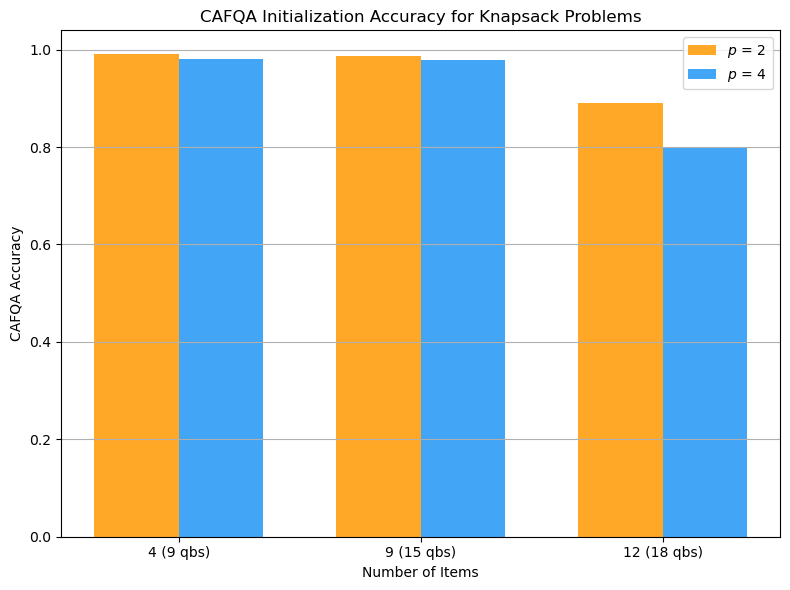

In [12]:
# Dummy data for two layers per number of items
item_sizes = [4, 9, 12]
layers = [2, 4]
# Example dummy CAFQA accuracy values for each (item_size, layer)
dummy_accuracies = {
    (4, 2): 0.99, (4, 4): 0.98,
    (9, 2): 44194/44800.5, (9, 4): 43860/44800.5,
    (12, 2): 148133.5/166236.5, (12, 4): 132867/166326.5
}

# Prepare data for plotting
bar_width = 0.35
index = np.arange(len(item_sizes))

layer1 = [dummy_accuracies[(n, 2)] for n in item_sizes]
layer2 = [dummy_accuracies[(n, 4)] for n in item_sizes]

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(index - bar_width/2, layer1, bar_width, label='$p$ = 2', color='#FFA726')
ax.bar(index + bar_width/2, layer2, bar_width, label='$p$ = 4 ', color='#42A5F5')

ax.set_xticks(index)
ax.set_xticklabels([str(n) for n in item_sizes])
ax.set_xlabel('Number of Items')
ax.set_ylabel('CAFQA Accuracy')
ax.set_title('CAFQA Initialization Accuracy for Knapsack Problems')
ax.legend()
ax.set_xticklabels(["4 (9 qbs)", "9 (15 qbs)","12 (18 qbs)"])
ax.grid(axis='y')
plt.tight_layout()
plt.show()
